# Exercises for Chapter 14, "Working with logistic regression"

In [40]:
import os
import sys

import numpy

from matplotlib import pyplot
from scipy import special

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [41]:
prng_builder = bg_ros.PRNGBuilder("""
    This is Chapter 14, wherein our heroes work with logistic regression in
    fun and fascinating ways.  I'm doing these exercises well after actually
    reading the material so I'll have to page a lot of it back in as it goes.
    I think it's... mostly adding interaction features?  We'll see.
""")

## 14.1, Graphing binary data and logistic regression

> Reproduce Figure 14.1 with the model,
> $\text{Pr}(y =1) = \text{logit}^{-1}(0.4 - 0.3x)$, with 50 data points $x$
> sampled uniformly in the range $[A, B]$. (In Figure 14.1 the $x$’s were drawn
> from a normal distribution.) Choose the values $A$ and $B$ so that the plot
> includes a zone where values of $y$ are all 1, a zone where they are all 0,
> and a band of overlap in the middle.

In [42]:
rng = prng_builder.new('Exercise 14.1, reproducing a figure')

In [43]:
a, b = (0.4, -0.3)

In [44]:
# From the logistic probability density function, we want the latent
# linear-predictor variable z to range from -6 to 6.
hi = (-6 - a) / b
lo = (6 - a) / b
print(f'[A, B] = [{lo: 0.1f}, {hi: 0.1f}]')

[A, B] = [-18.7,  21.3]


In [45]:
xs = rng.uniform(low=lo, high=hi, size=50)
zs = a + b * xs
rs = rng.uniform(size=50)
ys = [1 if ri < si else 0 for (ri, si) in zip(rs, special.expit(zs))]

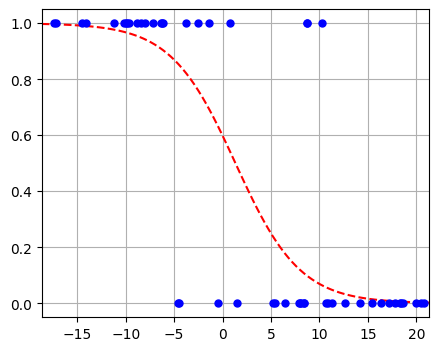

In [46]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(
    numpy.linspace(lo, hi, 100),
    special.expit(a + b * numpy.linspace(lo, hi, 100)),
    'r--',
)
ax.plot(xs, ys, 'b.', markersize=10)
ax.grid()
ax.set_xlim(lo, hi)
ax.set_axisbelow(True)
        